In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

In [2]:
araport=pd.read_table('Araport11_GFF3_genes_transposons.201606.gff.gz',skiprows=1,header=None)
araport.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
1,Chr1,Araport11,mRNA,3631.0,5899.0,.,+,.,ID=AT1G01010.1;Parent=AT1G01010;Name=AT1G01010...
2,Chr1,Araport11,five_prime_UTR,3631.0,3759.0,.,+,.,ID=AT1G01010:five_prime_UTR:1;Parent=AT1G01010...
3,Chr1,Araport11,exon,3631.0,3913.0,.,+,.,ID=AT1G01010:exon:1;Parent=AT1G01010.1;Name=NA...
4,Chr1,Araport11,CDS,3760.0,3913.0,.,+,0,ID=AT1G01010:CDS:1;Parent=AT1G01010.1;Name=NAC...


In [3]:
araport_gene=araport.loc[araport[2]=='gene']
araport_gene.head()

,0,1,2,3,4,5,6,7,8
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...


In [4]:
araport_gene['gene']=araport_gene[8].astype(str).str[3:12]
araport_gene.head()

<ipython-input-4-202a01519162>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  araport_gene['gene']=araport_gene[8].astype(str).str[3:12]


,0,1,2,3,4,5,6,7,8,gene
0,Chr1,Araport11,gene,3631.0,5899.0,.,+,.,ID=AT1G01010;Name=AT1G01010;Note=NAC domain co...,AT1G01010
19,Chr1,Araport11,gene,6788.0,9130.0,.,-,.,ID=AT1G01020;Name=AT1G01020;Note=ARV1 family p...,AT1G01020
105,Chr1,Araport11,gene,11101.0,11372.0,.,+,.,ID=AT1G03987;locus_type=long_noncoding_rna;Nam...,AT1G03987
109,Chr1,Araport11,gene,11649.0,13714.0,.,-,.,ID=AT1G01030;Name=AT1G01030;Note=AP2/B3-like t...,AT1G01030
140,Chr1,Araport11,gene,23121.0,31227.0,.,+,.,ID=AT1G01040;Name=AT1G01040;Note=dicer-like 1;...,AT1G01040


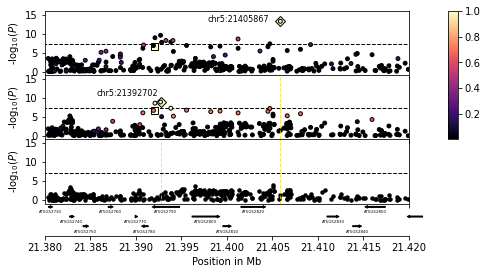

In [5]:
start = 21380000
end = 21420000


def load(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df)


#Function to import conditional GWAS                             
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    return(df.loc[(df['chr'] == 5) &
            (df['ps'] > start) &
            (df['ps'] < end)])

#Function to plot conditional GWAS
def multiplot(axe, dataframe, position1, position2):
    sns.scatterplot(x='ps',
                y='P',
                data=dataframe,
                palette='magma',
                hue='R2',
                marker='o',
                s=15,
                linewidth=1,
                edgecolor='k',
                legend=False,
                zorder=2,
                ax=axe)
    axe.hlines(y=-np.log10(0.05/len(SNP)),
                 xmin=min(SNP['position']),
                 xmax=max(SNP['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
    #              alpha=0.4,
                 zorder=1)

#     axe.annotate(text,xy=(21381000,10),xytext=(21381000,10),fontsize=8)
    axe.set_xlim(start,end)
    axe.set_xlabel('')
    axe.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    axe.set_xticklabels([])
    axe.set_ylim(-1,16)
    axe.yaxis.set_major_locator(ticker.MultipleLocator(5))
    if position1 != 0 and position2 == 0:
        axe.axvline(x=position1,linewidth=1,linestyle='--',color='gold',alpha=0.7)
    elif position1 != 0 and position2 != 0:
        axe.axvline(x=position1,linewidth=1,linestyle='--',color='gold',alpha=0.7)
        axe.axvline(x=position2,linewidth=1,linestyle='--',color='gold',alpha=0.7)

# Import araport info
araport_zoom=araport_gene.loc[(araport_gene[0] == 'Chr5') & (araport_gene[3] > start) & (araport_gene[3] < end)]

# Plot
from matplotlib.gridspec import GridSpec

colors = plt.cm.magma(np.linspace(0,1,5))

def major_formatter(x, pos):
    y = x /1000000
    return "%.3f" % y




cm = 1/2.54
fig = plt.figure(figsize=(20*cm,12*cm))
gs = GridSpec(8, 6, figure=fig, hspace=0)

ax1 = fig.add_subplot(gs[0:2,0:5])
SNP=load('690_Mg_blues.assoc.txt.gz')
classic=parse('690_Mg_blues.assoc.txt.gz')
Chr5_21405867_ld=pd.read_table('Chr5_21405867.ld', sep = '\s+')
Chr5_21405867_ld.head()
zoom_21405867=pd.merge(classic,Chr5_21405867_ld,left_on='ps',right_on='BP_B')
multiplot(ax1, zoom_21405867, 0, 0)
SNP_21405867 = zoom_21405867.loc[zoom_21405867['ps'] == 21405867,'P'].values
ax1.plot(21405867,SNP_21405867,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
SNP_21391927=zoom_21405867.loc[zoom_21405867['ps'] == 21391927,'P'].values
ax1.plot(21391927,SNP_21391927,'s',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax1.annotate('chr5:21405867',xy=(21405867-8000,SNP_21405867-0.2),xytext=(21405867-8000,SNP_21405867-0.2),fontsize=8)

ax2 = fig.add_subplot(gs[2:4,0:5])
Chr5_21392702=parse('690_Mg_blues_Chr5_21405867.assoc.txt.gz')
Chr5_21392702_ld=pd.read_table('Chr5_21392702.ld', sep = '\s+')
Chr5_21392702_ld.head()
zoom_21392702=pd.merge(Chr5_21392702,Chr5_21392702_ld,left_on='ps',right_on='BP_B')
multiplot(ax2, zoom_21392702, 21405867, 0)
SNP_21392702=zoom_21392702.loc[zoom_21392702['ps'] == 21392702,'P'].values
ax2.plot(21392702,SNP_21392702,'D',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
SNP_21391927=zoom_21392702.loc[zoom_21392702['ps'] == 21391927,'P'].values
ax2.plot(21391927,SNP_21391927,'s',markersize=7,color=colors[4],linewidth=0.5,mec='k',zorder=1)
ax2.annotate('chr5:21392702',xy=(21392702-7000,SNP_21392702+1.5),xytext=(21392702-7000,SNP_21392702+1.5),fontsize=8)

Chr5_21392702_21405867=parse('690_Mg_blues_Chr5_21405867_21392702.assoc.txt.gz')
ax3 = fig.add_subplot(gs[4:6,0:5])
sns.scatterplot(x='ps',
        y='P',
        data=Chr5_21392702_21405867,
        color='k',
        marker='o',
        s=15,
        linewidth=0.5,
        edgecolor='k',
        legend=False,
        zorder=2,
        ax=ax3)
ax3.set_xlim(start,end)
ax3.set_xlabel('')
ax3.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax3.set_xticklabels([])
ax3.set_ylim(-1,16)
ax3.axvline(x=21392702,linewidth=1,linestyle='--',color='gold',alpha=0.7)
ax3.axvline(x=21405867,linewidth=1,linestyle='--',color='gold',alpha=0.7)
ax3.hlines(y=-np.log10(0.05/len(SNP)),
             xmin=min(SNP['position']),
             xmax=max(SNP['position']),
             color='0',
             linestyle='--',
             linewidth=1,
#              alpha=0.4,
             zorder=1)
ax3.yaxis.set_major_locator(ticker.MultipleLocator(5))

#Gene information
ax4 = fig.add_subplot(gs[6,:5])
ax4.set_xlim(ax1.get_xlim())
# ax2.axis("off")
n=1

def arrow(var,x,y):
    if var[6] == '+':
        ax4.annotate('',(var[4], x),(var[3], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax4.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
    if var[6] == '-': 
        ax4.annotate('',(var[3], x),(var[4], x),arrowprops=dict(arrowstyle='simple,head_length=0.25,head_width=.25,tail_width=.10',color='0'))
        ax4.annotate(var['gene'],(var[3]+((var[4]-var[3])/2), y),(var[3]+((var[4]-var[3])/2), y),ha='center',fontsize=4)
        
        
n=0
for index, row in araport_zoom.iterrows():
    if row['gene'][8] == '0':
        if n == 0:
            arrow(row,0.9,0.7)
            n+=1
        elif n == 1:
            arrow(row,0.6,0.4)
            n+=1
        elif n == 2:
            arrow(row,0.3,0.1)
            n=0
    

ax4.xaxis.set_major_formatter(major_formatter)
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
# ax4.xaxis.set_major_locator(ticker.MultipleLocator(10000))
ax4.set_yticklabels([])
# sns.despine(trim=True,ax=ax4)
ax4.axes.get_yaxis().set_visible(False)
ax4.spines["left"].set_visible(False)
ax4.spines["right"].set_visible(False)
# ax4.spines["top"].set_visible(False)

ax4.set_yticklabels([])
ax4.set_xlabel('Position in Mb',fontsize=10)


# Add legend
norm = plt.Normalize(zoom_21392702['R2'].min(), zoom_21392702['R2'].max())
sm = plt.cm.ScalarMappable(norm=norm,cmap='magma')
sm.set_array([])
ax5 = fig.add_subplot(gs[0:4,5])
ax5.axis('off')

# ax3.get_legend().remove()
axins = inset_axes(ax5,
                    width="15%",  
                    height="100%",
                    loc='center',
                    borderpad=-5
                   )
ax5.figure.colorbar(sm,pad=0.05,shrink=0.8,cax=axins,orientation="vertical")
plt.savefig("FigS7.pdf", format="pdf",bbox_inches="tight")